In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from ctrlab import crazyflie
from ctrlab.envs.hover import Hover
from ctrlab.rl.ppo import PPO

mass = crazyflie['mass']
inertia = crazyflie['inertia']
G1 = crazyflie['G1']
tau = crazyflie['tau']

env = Hover(num_envs=1, 
            mass=mass, 
            inertia=inertia, 
            G1 = G1,
            tau = tau,
            dt = np.float32(0.01)
            )

ppo = PPO(env, 
          hidden_dim=64, 
          num_layers=2, 
          activation='tanh', 
          n_steps=500, 
          batch_size=4096,  
          n_epochs=10, 
          gamma=0.999, 
          lr=3e-4,
          policy_clip=0.1,
          gae_lambda=0.95,
          directory='tmp/ppo')

ppo.load_models()
    


Loading models...


In [2]:
obs, _ = env.reset(np.ones(env.num_envs, dtype=bool))
obs = torch.tensor(obs, dtype=torch.float32)

done = np.zeros(1, dtype=bool)

states = []
actions = []

while not done[0]:
    # Get action
    mean, std = ppo.actor(obs)
    action = mean.detach()

    # Step environment
    actions_clipped = torch.clamp(action, -1, 1)
    obs, reward, terminated, truncated, info = env.step(actions_clipped.numpy())
    
    obs = torch.tensor(obs, dtype=torch.float32)
    # states.append(env.drone.states[0,:])
    states.append(obs.numpy()[0])
    actions.append(actions_clipped[0,:].numpy())
    
    done = terminated | truncated
    
states = np.asarray(states)
actions = np.asarray(actions)

print(f"Num steps: {len(states)}")

Num steps: 9


In [3]:
# Create figure
fig = go.Figure()

# Trajectory line
fig.add_trace(go.Scatter3d(
    x=states[:, 0],
    y=states[:, 1],
    z=states[:, 2],
    mode='lines',
    line=dict(color='black'),
    name='Trajectory'
))

# Start point
fig.add_trace(go.Scatter3d(
    x=[states[0, 0]],
    y=[states[0, 1]],
    z=[states[0, 2]],
    mode='markers',
    marker=dict(color='red', size=6),
    name='Start'
))

# End point
fig.add_trace(go.Scatter3d(
    x=[states[-1, 0]],
    y=[states[-1, 1]],
    z=[states[-1, 2]],
    mode='markers',
    marker=dict(color='green', size=6),
    name='End'
))

# Goal at origin
fig.add_trace(go.Scatter3d(
    x=[0],
    y=[0],
    z=[0],
    mode='markers',
    marker=dict(color='blue', size=6),
    name='Goal'
))

# Layout
fig.update_layout(
    scene=dict(
        xaxis=dict(title='x', range=[-1.2, 1.2]),
        yaxis=dict(title='y', range=[-1.2, 1.2]),
        zaxis=dict(title='z', range=[1.2, -1.2])  # Inverted Z-axis
    ),
    width=800,
    height=800,
    showlegend=True
)

fig.show()

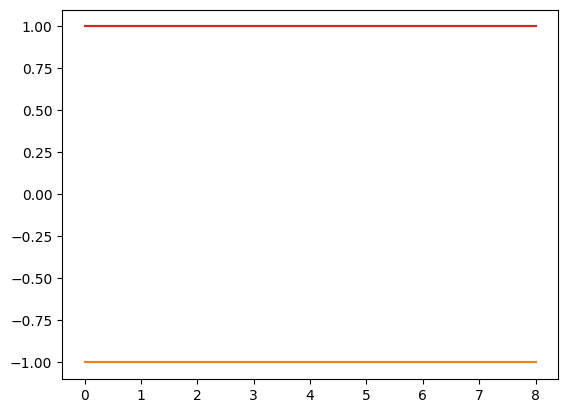

In [4]:
plt.plot(actions[:,0])
plt.plot(actions[:,1])
plt.plot(actions[:,2])
plt.plot(actions[:,3])

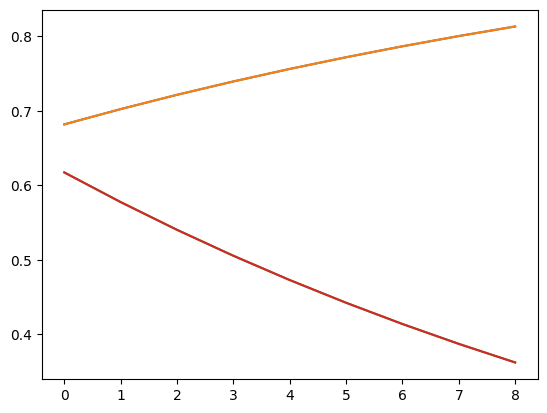

In [5]:
plt.plot(states[:,-1])
plt.plot(states[:,-2])
plt.plot(states[:,-3])
plt.plot(states[:,-4])

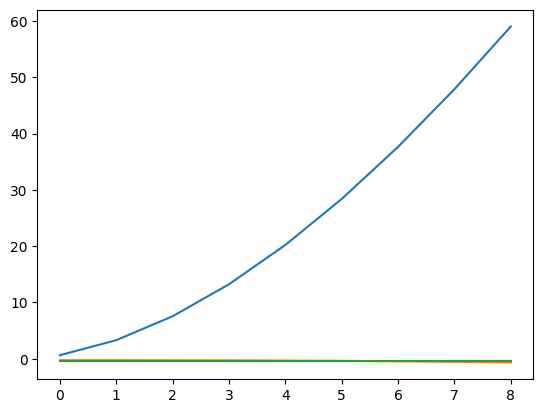

In [6]:
plt.plot(states[:,10])
plt.plot(states[:,11])
plt.plot(states[:,12])